# 1) Config + load features (X) and labels (y)

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer


FEATURE_PATH = "../data/feature_vectors/X_full.tsv"   # swap to X_kmer.tsv, X_binary.tsv, or X_full.tsv later


In [2]:
df_feat = pd.read_csv(FEATURE_PATH, sep="\t")
label_col = "label" if "label" in df_feat.columns else df_feat.columns[-1]

X = df_feat.drop(columns=[label_col]).to_numpy(dtype=float)
y = df_feat[label_col].to_numpy(dtype=float)

print("Loaded:", FEATURE_PATH, "| X:", X.shape, "| y:", y.shape, "| y range:", (y.min(), y.max()))


Loaded: ../data/feature_vectors/X_full.tsv | X: (4435, 610) | y: (4435,) | y range: (0.0, 99.0)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_ind, y_train, y_ind = train_test_split(
    X, y, test_size=0.20, shuffle=True, random_state=42
)
print("Train:", X_train.shape, " | Independent 20%:", X_ind.shape)


Train: (3548, 610)  | Independent 20%: (887, 610)


# PCC scorer + 10-fold CV on the 80% (Ridge + scaling)

In [6]:

def _pcc(y_true, y_pred):
    return float(np.corrcoef(y_true, y_pred)[0, 1])

pcc_scorer = make_scorer(_pcc, greater_is_better=True)
cv = KFold(n_splits=10, shuffle=True, random_state=42)

ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=42))
])

pcc_cv = cross_val_score(ridge, X_train, y_train, cv=cv, scoring=pcc_scorer, n_jobs=-1)
print("Ridge (alpha=1.0) — PCC, 10-fold CV on 80%")
print("  per-fold:", np.round(pcc_cv, 4))
print("  mean ± std: {:.4f} ± {:.4f}".format(pcc_cv.mean(), pcc_cv.std()))


Ridge (alpha=1.0) — PCC, 10-fold CV on 80%
  per-fold: [0.2063 0.3159 0.3413 0.3455 0.4514 0.3645 0.2642 0.3703 0.364  0.3374]
  mean ± std: 0.3361 ± 0.0621


# Fit on full 80% and report PCC on the 20% holdout

In [8]:
ridge.fit(X_train, y_train)
y_pred_ind = ridge.predict(X_ind)
print("Ridge (alpha=1.0) — PCC on independent 20%:", _pcc(y_ind, y_pred_ind))


Ridge (alpha=1.0) — PCC on independent 20%: 0.4431903371126918


# Hyperparameter tuning for Ridge (log-alpha grid)

In [9]:
from sklearn.model_selection import GridSearchCV

grid = {"model__alpha": np.logspace(-4, 3, 20)}  # 1e-4 .. 1e3
ridge_base = Pipeline([("scaler", StandardScaler()),
                       ("model", Ridge(random_state=42))])

gs = GridSearchCV(ridge_base, grid, scoring=pcc_scorer, cv=cv, n_jobs=-1, refit=True)
gs.fit(X_train, y_train)

print("Best CV PCC (Ridge): {:.4f}  | best alpha: {}".format(gs.best_score_, gs.best_params_["model__alpha"]))

# Evaluate tuned model on independent 20%
y_pred_ind_best = gs.best_estimator_.predict(X_ind)
print("Tuned Ridge — PCC on independent 20%:", _pcc(y_ind, y_pred_ind_best))


Best CV PCC (Ridge): 0.3486  | best alpha: 78.47599703514607
Tuned Ridge — PCC on independent 20%: 0.44182422878189564


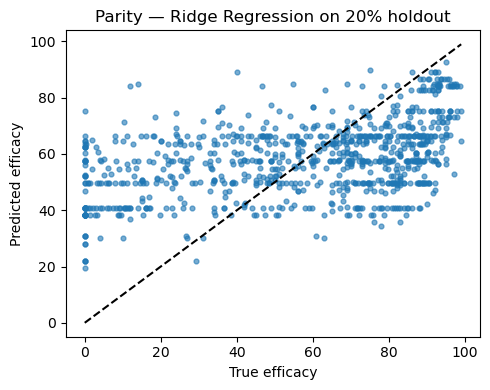

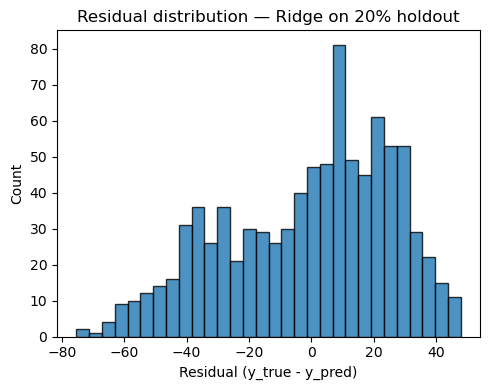

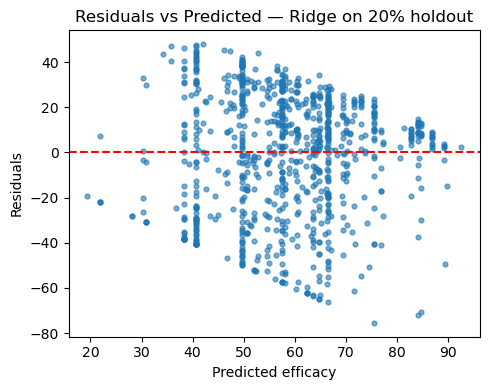

In [11]:
import matplotlib.pyplot as plt

# Use tuned model from GridSearch if available, else the baseline ridge
ridge_model = gs.best_estimator_ if 'gs' in locals() else ridge

# Predictions on the 20% independent set
y_pred_ind = ridge_model.predict(X_ind)

# --- Parity plot ---
plt.figure(figsize=(5,4))
plt.scatter(y_ind, y_pred_ind, alpha=0.6, s=12)
lims = [min(y_ind.min(), y_pred_ind.min()), max(y_ind.max(), y_pred_ind.max())]
plt.plot(lims, lims, "k--")
plt.xlabel("True efficacy")
plt.ylabel("Predicted efficacy")
plt.title("Parity — Ridge Regression on 20% holdout")
plt.tight_layout()
plt.show()

# --- Residuals histogram ---
res = y_ind - y_pred_ind
plt.figure(figsize=(5,4))
plt.hist(res, bins=30, alpha=0.8, edgecolor="k")
plt.xlabel("Residual (y_true - y_pred)")
plt.ylabel("Count")
plt.title("Residual distribution — Ridge on 20% holdout")
plt.tight_layout()
plt.show()

# --- Residuals vs Predicted ---
plt.figure(figsize=(5,4))
plt.scatter(y_pred_ind, res, alpha=0.6, s=12)
plt.axhline(0, ls="--", color="red")
plt.xlabel("Predicted efficacy")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted — Ridge on 20% holdout")
plt.tight_layout()
plt.show()


# END of FILE